In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multioutput import MultiOutputClassifier
import xgboost as xgb
import joblib

In [23]:
# ---------------------------------------------------------------------------
# CONFIG - edit to match your dataframe's real column/value names
# ---------------------------------------------------------------------------
TIME_COL = "timestamp"
GAME_ID_COL = "match"
IP_PORT_COL = "new_player.ip_port"           # present on connect rows
EVENT_TYPE_COL = "event_type"

CONNECT_EVENT_VALUE = "new_player"   # <-- set to your actual event_type value
CHEAT_EVENT_VALUE = "cheat"     # <-- set to your actual event_type value
#CHEATER_COL = "cheat.cheater_id"    

EXPLOIT_TYPE_COL = "cheat.type"                # exploit type string, on cheat rows

ENTRY_TYPE_COL = "entry_type"          # <-- set to your actual column name
EVENT_ENTRY_VALUE = "event"            # <-- set to your actual value
PACKET_ENTRY_VALUE = "packet"          # <-- set to your actual value
PACKET_ID_COL = "header.ids.ipaddress" # <-- connection-scoped id, present on packet rows
 
NEW_ADDRESS_EVENT_VALUE = "new_address"  # <-- event_type value that reveals PACKET_ID_COL -> ip
NEW_ADDRESS_ID_COL = "new_address.address_id"
NEW_ADDRESS_IP_COL = "new_address.ip"    # <-- the actual ip revealed on that event row


PLAYER_ID_COLS_BY_EVENT = {
    CONNECT_EVENT_VALUE: "new_player.player_id",
    CHEAT_EVENT_VALUE: "cheat.cheater_id",
    "health": "health.player_id",
    "movement": "movement.player_id",
    "weapon": "weapon.player_id"
    # ... add every other event_type here
}

RAW_PLAYER_ID_COLS = sorted(set(PLAYER_ID_COLS_BY_EVENT.values()))

def get_drop_cols() -> list[str]:
    """Computed at call-time (not frozen at import) so this can't go stale
    if GAME_ID_COL or other config vars are edited and only some cells are
    rerun in a notebook."""
    return RAW_PLAYER_ID_COLS + [
        EVENT_TYPE_COL, EXPLOIT_TYPE_COL, IP_PORT_COL, GAME_ID_COL,
         "frame", "outgoing", "entry_type", "hash_data", "ts", "session", "file", "header.ids.hash_data", "notification.type", "notification.extra_info_header.type", "movement.ts_client", "weapon.time", "dayofweek_last", "actor_player_id",  # other non-feature columns, edit freely
    ]

ONE_HOT_COLS = [
    "incoming", "event_type", "header.ids.sessionid", "new_player.update_ip_port", "weapon.ot", "weapon.target_id", "weapon.bone", "weapon.blind", "weapon.weapon", "weapon.cartridge_id", "phase_event.phase_name", "phase_event.start", "new_player.name"
]

NUMERIC_FEATURE_COLS = [
    "ind", "notification.extra_info_header.jitter_clock", "health.new_", "movement.dS", "movement.new_location.0", "movement.new_location.1", "movement.new_location.2", "weapon.dist", "bunches.count"
]

SEQUENCE_COL = "notification.seq"
ACKED_SEQUENCE_COL = "notification.acked_seq"
MONOTONIC_COUNTER_COLS = [SEQUENCE_COL, ACKED_SEQUENCE_COL]
WINDOW_SECONDS = 30
STRIDE_SECONDS = 10


# ---------------------------------------------------------------------------
# 1. Timestamp handling & Actor column
# ---------------------------------------------------------------------------
def prepare_time(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df[TIME_COL] = pd.to_datetime(df[TIME_COL], format='ISO8601', utc=True)
    df = df.sort_values([GAME_ID_COL, TIME_COL]).reset_index(drop=True)
    df["timestamp_iso"] = df[TIME_COL].apply(lambda ts: ts.isoformat())
    df["hour"] = df[TIME_COL].dt.hour
    df["dayofweek"] = df[TIME_COL].dt.dayofweek
    return df


def resolve_packet_actors(df: pd.DataFrame) -> pd.DataFrame:
    """Packets carry PACKET_ID_COL (a connection-scoped id), not player_id.
    Resolve it in two static, per-game hops -- not time-restricted joins,
    because of the ordering quirk: the new_address row revealing what an id
    maps to is typically PRECEDED by the very packet using that id, so a
    backward-looking asof join would leave early packets unresolved.
 
      Hop 1: PACKET_ID_COL -> ip, from ALL new_address rows in that game.
      Hop 2: ip (port-stripped) -> player_id, from ALL connect-event rows
             in that game (same binding used elsewhere for ip:port).
    """
    df = df.copy()
    connect_col = PLAYER_ID_COLS_BY_EVENT.get(CONNECT_EVENT_VALUE)
 
    if NEW_ADDRESS_IP_COL not in df.columns or NEW_ADDRESS_ID_COL not in df.columns \
            or PACKET_ID_COL not in df.columns or connect_col is None:
        print("WARNING: packet actor resolution skipped -- NEW_ADDRESS_IP_COL, "
              "NEW_ADDRESS_ID_COL, PACKET_ID_COL, or the connect event's player-id "
              "column not found. Check those config values against your actual schema.")
        return df
 
    # Hop 1: id -> ip:port, static per game (built from ALL occurrences, not
    # asof). new_address rows use their own column name for the id being
    # assigned (NEW_ADDRESS_ID_COL), not PACKET_ID_COL -- rename to match
    # so the merge below can join on it.
    id_to_ip = (
        df.loc[df[EVENT_TYPE_COL] == NEW_ADDRESS_EVENT_VALUE, [GAME_ID_COL, NEW_ADDRESS_ID_COL, NEW_ADDRESS_IP_COL]]
        .dropna()
        .drop_duplicates(subset=[GAME_ID_COL, NEW_ADDRESS_ID_COL], keep="last")
        .rename(columns={NEW_ADDRESS_ID_COL: PACKET_ID_COL})
    )
 
    # Hop 2: ip:port -> player_id, static per game. new_address.ip already
    # includes the port, same format as the connect event's IP_PORT_COL, so
    # this is a direct match -- no port-stripping needed.
    ip_to_player = (
        df.loc[df[EVENT_TYPE_COL] == CONNECT_EVENT_VALUE, [GAME_ID_COL, IP_PORT_COL, connect_col]]
        .dropna()
        .drop_duplicates(subset=[GAME_ID_COL, IP_PORT_COL], keep="last")
        .rename(columns={connect_col: "_resolved_player_id", IP_PORT_COL: NEW_ADDRESS_IP_COL})
        [[GAME_ID_COL, NEW_ADDRESS_IP_COL, "_resolved_player_id"]]
    )
 
    packet_mask = df[ENTRY_TYPE_COL] == PACKET_ENTRY_VALUE
    packet_rows = df.loc[packet_mask, [GAME_ID_COL, PACKET_ID_COL]].copy()
    packet_rows["_row_idx"] = packet_rows.index  # preserve original index across the merges below
 
    packet_rows = packet_rows.merge(id_to_ip, on=[GAME_ID_COL, PACKET_ID_COL], how="left")
    packet_rows = packet_rows.merge(ip_to_player, on=[GAME_ID_COL, NEW_ADDRESS_IP_COL], how="left")
 
    resolved = packet_rows.set_index("_row_idx")["_resolved_player_id"]
    unresolved_count = resolved.isna().sum()
    if unresolved_count:
        print(f"WARNING: {unresolved_count}/{len(resolved)} packet rows could not be "
              "resolved to a player_id via the id->ip->player chain")
 
    df.loc[resolved.index, "actor_player_id"] = df.loc[resolved.index, "actor_player_id"].fillna(resolved)
    return df
 
 
def add_actor_column(df: pd.DataFrame) -> pd.DataFrame:
    """Coalesce every row's player_id into one column. Event rows use
    event_type + PLAYER_ID_COLS_BY_EVENT; packet rows are resolved via
    resolve_packet_actors' two-hop id->ip->player chain, since they don't
    carry player_id at all."""
    df = df.copy()
    df["actor_player_id"] = np.nan
 
    for event_type, col in PLAYER_ID_COLS_BY_EVENT.items():
        if col not in df.columns:
            continue
        mask = df[EVENT_TYPE_COL] == event_type
        df.loc[mask, "actor_player_id"] = df.loc[mask, col]
 
    df = resolve_packet_actors(df)
    return df
 
 
def report_actor_coverage(df: pd.DataFrame) -> pd.DataFrame:
    """Sanity check: what fraction of rows, broken down by entry_type, got
    a resolved actor_player_id? Run this right after add_actor_column --
    any entry_type showing 0% coverage means its player-id column is
    misconfigured, and every feature built from those rows will be
    silently empty (the exact bug that caused the sequence/jitter
    degeneracy)."""
    if ENTRY_TYPE_COL not in df.columns:
        print(f"'{ENTRY_TYPE_COL}' not found in dataframe -- check ENTRY_TYPE_COL config.")
        return pd.DataFrame()
    report = (
        df.assign(_resolved=df["actor_player_id"].notna())
        .groupby(ENTRY_TYPE_COL)["_resolved"]
        .agg(["sum", "count"])
        .rename(columns={"sum": "resolved", "count": "total"})
    )
    report["pct_resolved"] = (100 * report["resolved"] / report["total"]).round(1)
    print(report.to_string())
    return report
 
 
# ---------------------------------------------------------------------------
# 2. Resolve cheat events -> (game_id, timestamp, ip_port, exploit_type)
# ---------------------------------------------------------------------------
def resolve_cheat_events(df: pd.DataFrame) -> pd.DataFrame:
    connects = (
        df[df[EVENT_TYPE_COL] == CONNECT_EVENT_VALUE]
        [[GAME_ID_COL, "actor_player_id", TIME_COL, IP_PORT_COL]]
        .sort_values(TIME_COL)
    )
    cheats = (
        df[df[EVENT_TYPE_COL] == CHEAT_EVENT_VALUE]
        [[GAME_ID_COL, "actor_player_id", TIME_COL, EXPLOIT_TYPE_COL]]
        .sort_values(TIME_COL)
    )
 
    if cheats.empty:
        return pd.DataFrame(columns=[GAME_ID_COL, TIME_COL, "actor_player_id", IP_PORT_COL, EXPLOIT_TYPE_COL])
 
    # backward asof-join: for each cheat event, find the most recent
    # "connected" event for that same player in that same game -- this
    # correctly handles a player reconnecting with a new ip:port.
    resolved = pd.merge_asof(
        cheats,
        connects,
        on=TIME_COL,
        by=[GAME_ID_COL, "actor_player_id"],
        direction="backward",
    )
 
    unresolved = resolved[IP_PORT_COL].isna().sum()
    if unresolved:
        print(f"WARNING: {unresolved} cheat events had no prior connect event to resolve ip:port "
              "(ip:port will be missing for these, but they're still usable for training since "
              "targets are now matched by player identity, not ip:port)")
 
    # actor_player_id + exploit_type are essential for matching targets to
    # player-window rows; ip_port may legitimately be missing (see warning
    # above) and is kept only for human-readable reporting/traceability.
    return resolved[[GAME_ID_COL, TIME_COL, "actor_player_id", IP_PORT_COL, EXPLOIT_TYPE_COL]].dropna(
        subset=["actor_player_id", EXPLOIT_TYPE_COL]
    )
 
 
# ---------------------------------------------------------------------------
# 3. Derive the exploit-type vocabulary from resolved cheat events (not
#    hardcoded). Player identity is now the ROW itself (see build_dataset),
#    so the target vocabulary is just exploit types, not ip:port x type
#    combinations -- much denser positive-example counts per label.
# ---------------------------------------------------------------------------
def derive_type_vocab(resolved_cheats: pd.DataFrame) -> list[str]:
    return sorted(resolved_cheats[EXPLOIT_TYPE_COL].dropna().unique().tolist())


In [24]:
# ---------------------------------------------------------------------------
# 4. Time-based windows, built per game, including empty windows
# ---------------------------------------------------------------------------
def make_time_windows(group_df: pd.DataFrame, window_seconds: int, stride_seconds: int):
    # .to_numpy() on a tz-aware column returns an object array of tz-aware
    # Timestamps, not real datetime64 -- force conversion to naive-UTC
    # datetime64[ns] so downstream arithmetic and pd.Timestamp(..., tz="UTC")
    # calls work correctly.
    times = group_df[TIME_COL].to_numpy(dtype="datetime64[ns]")
    if len(times) == 0:
        return
    window = np.timedelta64(window_seconds, "s")
    stride = np.timedelta64(stride_seconds, "s")
    start, t_end = times[0], times[-1]
    while start <= t_end:
        end = start + window
        lo = np.searchsorted(times, start, side="left")
        hi = np.searchsorted(times, end, side="left")
        yield group_df.iloc[lo:hi], start, end
        start = start + stride
 
 
# ---------------------------------------------------------------------------
# 4b. Monotonic counter aggregation (sequence numbers, ack numbers)
# ---------------------------------------------------------------------------
def aggregate_monotonic_counters(window_df: pd.DataFrame, window_seconds: float) -> dict:
    """Raw mean/min/max of a monotonically-increasing counter mostly just
    encodes elapsed session time, not window-local behavior. Instead:
      - {col}_rate: net increase per second (throughput -- flooding/lag
        switch shows up as abnormal rate)
      - {col}_delta_mean/std/max: stats of consecutive differences within
        the window (gaps suggest dropped/delayed packets)
      - {col}_regression_count: how many times the value went BACKWARDS
        between consecutive rows -- should be ~0 for a true counter, so
        any positive count is a strong replay/spoofing signal
      - seq_ack_lag_mean/max: outstanding (unacknowledged) packets, a
        classic lag-switch / packet-manipulation fingerprint
    """
    agg = {}
 
    for col in MONOTONIC_COUNTER_COLS:
        if col not in window_df.columns:
            continue
        values = window_df[col].dropna().to_numpy(dtype=float)
        if len(values) < 2:
            agg[f"{col}_rate"] = 0.0
            agg[f"{col}_delta_mean"] = agg[f"{col}_delta_std"] = agg[f"{col}_delta_max"] = 0.0
            agg[f"{col}_regression_count"] = 0
            continue
        deltas = np.diff(values)
        agg[f"{col}_rate"] = (values[-1] - values[0]) / window_seconds if window_seconds > 0 else 0.0
        agg[f"{col}_delta_mean"] = float(deltas.mean())
        agg[f"{col}_delta_std"] = float(deltas.std())
        agg[f"{col}_delta_max"] = float(deltas.max())
        agg[f"{col}_regression_count"] = int((deltas < 0).sum())
 
    if SEQUENCE_COL in window_df.columns and ACKED_SEQUENCE_COL in window_df.columns:
        lag = (window_df[SEQUENCE_COL] - window_df[ACKED_SEQUENCE_COL]).dropna()
        agg["seq_ack_lag_mean"] = float(lag.mean()) if len(lag) else 0.0
        agg["seq_ack_lag_max"] = float(lag.max()) if len(lag) else 0.0
    else:
        agg["seq_ack_lag_mean"] = 0.0
        agg["seq_ack_lag_max"] = 0.0
 
    return agg

In [25]:
# ---------------------------------------------------------------------------
# 5. Window aggregation -> one row of X (handles empty windows)
# ---------------------------------------------------------------------------
def aggregate_window(window_df: pd.DataFrame, start_ts, end_ts, event_types: list[str], game_id) -> dict:
    agg = {"row_count": len(window_df), GAME_ID_COL: game_id}
    window_seconds = (end_ts - start_ts) / np.timedelta64(1, "s")
    agg.update(aggregate_monotonic_counters(window_df, window_seconds))
 
    # per-event-type counts -- this is what replaces the dropped raw
    # event_type column: "12 shot events, 40 movement events" etc.
    counts = window_df[EVENT_TYPE_COL].value_counts() if len(window_df) else pd.Series(dtype=int)
    for et in event_types:
        agg[f"count_{et}"] = int(counts.get(et, 0))
 
    # packet rows don't populate event_type, so they never show up in the
    # counts above -- count them explicitly. Packet volume/rate itself can
    # be a signal (e.g. unusually low/bursty rates for lag switching).
    if ENTRY_TYPE_COL in window_df.columns:
        agg["packet_row_count"] = int((window_df[ENTRY_TYPE_COL] == PACKET_ENTRY_VALUE).sum())
    else:
        agg["packet_row_count"] = 0
 
    if len(window_df) == 0:
        for col in NUMERIC_FEATURE_COLS:
            agg[f"{col}_mean"] = agg[f"{col}_std"] = 0.0
            agg[f"{col}_min"] = agg[f"{col}_max"] = agg[f"{col}_last"] = 0.0
        for col in ONE_HOT_COLS:
            agg[col] = "none"
        #agg["hour_last"] = pd.Timestamp(start_ts).hour
        #agg["dayofweek_last"] = pd.Timestamp(start_ts).dayofweek
    else:
        for col in NUMERIC_FEATURE_COLS:
            agg[f"{col}_mean"] = window_df[col].mean()
            agg[f"{col}_std"] = window_df[col].std()
            agg[f"{col}_min"] = window_df[col].min()
            agg[f"{col}_max"] = window_df[col].max()
            agg[f"{col}_last"] = window_df[col].iloc[-1]
        for col in ONE_HOT_COLS:
            agg[col] = window_df[col].iloc[-1]
        #agg["hour_last"] = window_df["hour"].iloc[-1]
        #agg["dayofweek_last"] = window_df["dayofweek"].iloc[-1]
 
    agg["window_start_iso"] = pd.Timestamp(start_ts, tz="UTC").isoformat()
    agg["window_end_iso"] = pd.Timestamp(end_ts, tz="UTC").isoformat()
    return agg

 
 
# ---------------------------------------------------------------------------
# 6. Target: exploit types THIS SPECIFIC PLAYER committed in this window
# ---------------------------------------------------------------------------
def build_player_target(resolved_cheats_for_game: pd.DataFrame, player_id, start_ts, end_ts) -> list[str]:
    # start_ts/end_ts arrive as naive datetime64 (see make_time_windows);
    # resolved_cheats_for_game[TIME_COL] is tz-aware, so both sides must
    # match before comparing.
    start_ts = pd.Timestamp(start_ts, tz="UTC")
    end_ts = pd.Timestamp(end_ts, tz="UTC")
    mask = (
        (resolved_cheats_for_game["actor_player_id"] == player_id)
        & (resolved_cheats_for_game[TIME_COL] >= start_ts)
        & (resolved_cheats_for_game[TIME_COL] < end_ts)
    )
    return resolved_cheats_for_game.loc[mask, EXPLOIT_TYPE_COL].tolist()
 
 
# ---------------------------------------------------------------------------
# 6b. "Others" context: symptoms visible in OTHER players' own telemetry,
# not the suspect's. Network-based exploits (lag switching, packet
# manipulation) often show up as desync/rubber-banding in everyone ELSE,
# while the cheater's own traffic looks close to normal.
# ---------------------------------------------------------------------------
IDENTITY_KEYS = {GAME_ID_COL, "actor_player_id", "window_start_iso", "window_end_iso"}

OTHERS_AGG_STATS = ["mean", "max"]
 
def aggregate_others(others_feats: list[dict], reference_feat: dict) -> dict:
    """Aggregate a list of ALREADY-COMPUTED per-player feature dicts (each
    correctly self-scoped, including their own monotonic counter deltas)
    into a single 'others_*' context block for one player's row.
 
    IMPORTANT: this aggregates clean per-player SUMMARY NUMBERS, never raw
    telemetry rows from different players -- diffing/mixing raw rows across
    independent players' counters is the same bug we fixed earlier for
    sequence numbers, just reintroduced at the window level instead of the
    player level if done carelessly.
    """
    numeric_keys = [
        k for k, v in reference_feat.items()
        if k not in IDENTITY_KEYS and k not in ONE_HOT_COLS
        and isinstance(v, (int, float, np.integer, np.floating))
    ]
 
    out = {"window_other_player_count": len(others_feats)}
    if not others_feats:
        for k in numeric_keys:
            for stat in OTHERS_AGG_STATS:
                out[f"others_{k}_{stat}"] = 0.0
        return out
 
    for k in numeric_keys:
        values = np.array([f[k] for f in others_feats], dtype=float)
        all_nan = np.all(np.isnan(values))
        for stat in OTHERS_AGG_STATS:
            if all_nan:
                # every other player was also NaN for this feature this
                # window (e.g. a rare event type nobody triggered) -- NaN
                # is the honest answer, not 0; XGBoost handles NaN natively.
                out[f"others_{k}_{stat}"] = np.nan
            elif stat == "mean":
                out[f"others_{k}_{stat}"] = float(np.nanmean(values))   # typical other player's stat
            elif stat == "max":
                out[f"others_{k}_{stat}"] = float(np.nanmax(values))    # worst-affected other player
            elif stat == "sum":
                out[f"others_{k}_{stat}"] = float(np.nansum(values))    # total ambient magnitude -- NOTE:
                # nearly redundant with mean whenever window_other_player_count
                # is close to constant (sum ~= mean * count). Check
                # X_raw["window_other_player_count"].value_counts() before
                # re-enabling this; it's excluded from OTHERS_AGG_STATS by
                # default for exactly this reason.

    return out



In [26]:
# ---------------------------------------------------------------------------
# 7. Build the full dataset: one row per (window, player), never across games.
# Two-pass per window: (1) each active player's own features, (2) each
# player's row also gets an "others_" block built from everyone else's
# ALREADY-COMPUTED features -- see aggregate_others above.
# ---------------------------------------------------------------------------
def build_dataset(df: pd.DataFrame, window_seconds=WINDOW_SECONDS, stride_seconds=STRIDE_SECONDS):
    df = prepare_time(df)
    df = add_actor_column(df)
    report_actor_coverage(df)  # standing sanity check -- 0% for any entry_type means a misconfigured id column
 
    resolved_cheats = resolve_cheat_events(df)
    type_vocab = derive_type_vocab(resolved_cheats)
    event_types = sorted(df[EVENT_TYPE_COL].dropna().unique().tolist())
 
    # telemetry used for FEATURES excludes cheat-event rows entirely --
    # they state the answer directly and would leak.
    telemetry = df[df[EVENT_TYPE_COL] != CHEAT_EVENT_VALUE].copy()
 
    rows, targets = [], []
    for game_id, group in telemetry.groupby(GAME_ID_COL, sort=False):
        group = group.sort_values(TIME_COL)
        cheats_for_game = resolved_cheats[resolved_cheats[GAME_ID_COL] == game_id]
 
        for window_df, start_ts, end_ts in make_time_windows(group, window_seconds, stride_seconds):
            active_player_count = window_df["actor_player_id"].nunique()
            active_players = window_df["actor_player_id"].dropna().unique()
 
            # Pass 1: each active player's own correctly-scoped features.
            self_feats = {}
            for player_id in active_players:
                player_df = window_df[window_df["actor_player_id"] == player_id]
                feat = aggregate_window(player_df, start_ts, end_ts, event_types, game_id)
                feat["actor_player_id"] = player_id
                feat["window_active_player_count"] = active_player_count
                self_feats[player_id] = feat
 
            # Pass 2: attach an "others_" block built from everyone else's
            # already-computed Pass-1 numbers (not raw rows).
            for player_id in active_players:
                self_feat = self_feats[player_id]
                others_list = [f for pid, f in self_feats.items() if pid != player_id]
                combined = {**self_feat, **aggregate_others(others_list, self_feat)}
                rows.append(combined)
                targets.append(build_player_target(cheats_for_game, player_id, start_ts, end_ts))
 
    X = pd.DataFrame(rows)
    return X, targets, type_vocab
 
 
# ---------------------------------------------------------------------------
# 8. Feature encoding: drop leak-prone/irrelevant cols + one-hot
# ---------------------------------------------------------------------------
def encode_features(X: pd.DataFrame) -> pd.DataFrame:
    X = X.drop(columns=[c for c in get_drop_cols() if c in X.columns], errors="ignore")
    X = pd.get_dummies(X, columns=[c for c in ONE_HOT_COLS if c in X.columns], dummy_na=False, dtype=int)
    X = X.drop(columns=["window_start_iso", "window_end_iso"], errors="ignore")
 
    # Safety net: any column not explicitly one-hot'd or dropped above,
    # but still non-numeric, would silently reach XGBoost and fail deep
    # inside .fit() with a confusing error. Catch it here instead, with
    # the offending column name front and center.
    leftover_object_cols = X.select_dtypes(exclude=["number", "bool"]).columns.tolist()
    if leftover_object_cols:
        print(
            f"WARNING: {leftover_object_cols} were not in ONE_HOT_COLS or DROP_COLS -- "
            "auto one-hot encoding them now. Add them to the config explicitly to "
            "silence this warning and control the behavior intentionally."
        )
        X = pd.get_dummies(X, columns=leftover_object_cols, dummy_na=False, dtype=int)
 
    return X
 
 
# ---------------------------------------------------------------------------
# 9. Target encoding: vocabulary derived at train time, then persisted
# ---------------------------------------------------------------------------
def encode_targets(targets: list[list[str]], label_vocab: list[str]):
    mlb = MultiLabelBinarizer(classes=label_vocab)
    Y = mlb.fit_transform(targets)
    return Y, mlb
 
 
def per_player_report(X_raw: pd.DataFrame, test_idx, Y_test: np.ndarray, preds: np.ndarray, type_vocab: list[str], zero_division=0):
    """Per-player breakdown of detection performance across exploit types.
    Since each row is already (window, player), this is just a row filter --
    no label decomposition needed, unlike the old combined ip:port::type scheme."""
    from sklearn.metrics import classification_report
 
    player_ids_test = X_raw.loc[test_idx, "actor_player_id"].to_numpy()
    for player in sorted(set(player_ids_test)):
        mask = player_ids_test == player
        if mask.sum() == 0:
            continue
        print(f"\n--- Player {player} (n={mask.sum()} windows) ---")
        print(classification_report(Y_test[mask], preds[mask], target_names=type_vocab, zero_division=zero_division))
 
 
def fold_diagnostic(Y_subset: np.ndarray, labels: list[str], name: str, min_support: int = 3) -> pd.DataFrame:
    """Print positive-window counts for a fold's labels, flagging any with
    fewer than min_support positives -- those rows in classification_report
    are noise, not signal, no matter what number comes out."""
    counts = Y_subset.sum(axis=0)
    report = pd.DataFrame({"label": labels, "positive_count": counts}).sort_values("positive_count")
    thin = report[report["positive_count"] < min_support]
    if not thin.empty:
        print(f"  [{name}] {len(thin)}/{len(labels)} labels have < {min_support} positive windows in this fold:")
        print(thin.to_string(index=False))
    else:
        print(f"  [{name}] all {len(labels)} labels have >= {min_support} positive windows in this fold.")
    return report

In [27]:
# ---------------------------------------------------------------------------
# 10. Train + persist model AND encoder together (keeps inference consistent)
# ---------------------------------------------------------------------------
def train(X: pd.DataFrame, Y: np.ndarray) -> MultiOutputClassifier:
    base = xgb.XGBClassifier(
        objective="binary:logistic",
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        tree_method="hist",
        eval_metric="logloss",
    )
    clf = MultiOutputClassifier(base, n_jobs=-1)
    clf.fit(X, Y)
    return clf
 
 
def save_model(clf, mlb, feature_columns, path="cheat_model.joblib"):
    joblib.dump({"model": clf, "label_binarizer": mlb, "feature_columns": feature_columns}, path)
 
 
def load_model(path="cheat_model.joblib"):
    bundle = joblib.load(path)
    return bundle["model"], bundle["label_binarizer"], bundle["feature_columns"]
 
 
# ---------------------------------------------------------------------------
# 11. Sanity check: label balance before you commit to training
# ---------------------------------------------------------------------------
def label_balance_report(Y: np.ndarray, label_vocab: list[str]) -> pd.DataFrame:
    counts = Y.sum(axis=0)
    return pd.DataFrame({"label": label_vocab, "positive_windows": counts}).sort_values("positive_windows")


In [28]:
# ---------------------------------------------------------------------------
# 12. Feature diagnostics: correlation, importance, mutual information
# ---------------------------------------------------------------------------
def report_degenerate_features(X: pd.DataFrame) -> pd.DataFrame:
    """Flag zero-variance and all-NaN numeric features. These are exactly
    what shows up as BLANK (not zero) cells in a Spearman correlation
    heatmap -- correlation is mathematically undefined (0/0) for a constant
    series, and undefined for a series with no non-NaN values at all.
    A blank cell means "cannot vary in this data", not "weak relationship" --
    these are drop candidates regardless of what any importance metric says."""
    numeric_X = X.select_dtypes(include="number")
    zero_variance = numeric_X.columns[numeric_X.nunique(dropna=True) <= 1].tolist()
    all_nan = numeric_X.columns[numeric_X.isna().all()].tolist()
 
    report = pd.DataFrame({
        "feature": zero_variance + all_nan,
        "issue": ["zero_variance"] * len(zero_variance) + ["all_nan"] * len(all_nan),
    })
    if report.empty:
        print("No zero-variance or all-NaN features found.")
    else:
        print(f"{len(report)} degenerate feature(s) found (undefined correlation, safe to drop):")
        print(report.to_string(index=False))
    return report
 
 
def plot_target_correlation(X: pd.DataFrame, y_binary, method: str = "spearman", top_n: int = 30):
    """Rank-correlation of each numeric feature against a binary target.
    Spearman works fine against a 0/1 target -- it's just testing whether
    higher feature values monotonically associate with the positive class.
    Useful as a cheap first pass before trusting model-based importance."""
    import matplotlib.pyplot as plt
    from scipy.stats import spearmanr, pointbiserialr
 
    numeric_X = X.select_dtypes(include="number")
    y_arr = np.asarray(y_binary)
 
    corrs = {}
    for col in numeric_X.columns:
        if numeric_X[col].nunique() <= 1:
            corrs[col] = 0.0
            continue
        if method == "spearman":
            rho, _ = spearmanr(numeric_X[col], y_arr)
        else:
            rho, _ = pointbiserialr(y_arr, numeric_X[col])
        corrs[col] = 0.0 if np.isnan(rho) else rho
 
    corr_series = pd.Series(corrs).reindex(pd.Series(corrs).abs().sort_values(ascending=False).index).head(top_n)
 
    fig, ax = plt.subplots(figsize=(8, max(4, len(corr_series) * 0.3)))
    corr_series.sort_values().plot(kind="barh", ax=ax, color=["#d62728" if v < 0 else "#2ca02c" for v in corr_series.sort_values()])
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel(f"{method.title()} correlation with target")
    ax.set_title(f"Feature-target {method} correlation (top {top_n} by |r|)")
    plt.tight_layout()
    plt.show()
    return corr_series

from scipy.cluster import hierarchy as sch
from scipy.spatial.distance import squareform

def cluster_corr(corr_array, inplace=False):
    """
    Rearranges the correlation matrix so that groups of highly 
    correlated variables are next to each other.
    """
    # Calculate pairwise distances from the correlation matrix
    pairwise_distances  = 1 - abs(corr_array)
    
    # Perform hierarchical clustering
    linkage = sch.linkage(squareform(pairwise_distances), method='complete')
    
    # Determine cluster threshold and assign clusters
    cluster_distance_threshold = (pairwise_distances.max() / 2).values[0]
    idx_to_cluster_array = sch.fcluster(linkage, cluster_distance_threshold, 
                                        criterion='distance')
    
    # Get sorted indices based on cluster assignment
    idx = np.argsort(idx_to_cluster_array)
    
    if not inplace:
        corr_array = corr_array.copy()
        
    # Apply reordering
    if isinstance(corr_array, pd.DataFrame):
        return corr_array.iloc[idx, :].T.iloc[idx, :]
    return corr_array[idx, :][:, idx]   
 
def plot_feature_correlation_matrix(X: pd.DataFrame, method: str = "spearman"):
    """Correlation among features themselves -- high off-diagonal values
    flag redundant engineered features (e.g. mean/last often move together),
    which is useful for trimming the feature set without losing signal."""
    import matplotlib.pyplot as plt
 
    numeric_X = X.select_dtypes(include="number")
    corr = numeric_X.corr(method=method).fillna(0)
    n= corr.shape[0]
    for i in range(n):
        corr.iloc[i, i] = 1
    corr_sort = cluster_corr(corr)
 
    fig, ax = plt.subplots(figsize=(max(6, len(corr_sort.columns) * 0.4), max(5, len(corr_sort.columns) * 0.4)))
    im = ax.imshow(corr_sort, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr_sort.columns)))
    ax.set_xticklabels(corr_sort.columns, rotation=90, fontsize=7)
    ax.set_yticks(range(len(corr_sort.columns)))
    ax.set_yticklabels(corr_sort.columns, fontsize=7)
    fig.colorbar(im, ax=ax, shrink=0.8, label=f"{method} correlation")
    ax.set_title("Feature-feature correlation matrix")
    plt.tight_layout()
    plt.show()
    return corr_sort
 
 
def plot_feature_importance(clf: MultiOutputClassifier, feature_names: list[str], top_n: int = 25):
    """Mean XGBoost gain-based importance (feature_importances_ default)
    across all per-label estimators in the MultiOutputClassifier. Gain =
    average improvement in the loss from splits using that feature -- a
    feature with near-zero gain across every label is a strong drop
    candidate regardless of what the correlation plots show."""
    import matplotlib.pyplot as plt
 
    importances = np.array([est.feature_importances_ for est in clf.estimators_])
    mean_importance = importances.mean(axis=0)
 
    imp_series = pd.Series(mean_importance, index=feature_names).sort_values(ascending=False).head(top_n)
 
    fig, ax = plt.subplots(figsize=(8, max(4, len(imp_series) * 0.3)))
    imp_series.sort_values().plot(kind="barh", ax=ax, color="#1f77b4")
    ax.set_xlabel("Mean gain-based importance across all labels")
    ax.set_title(f"XGBoost feature importance (top {top_n}, averaged over {len(clf.estimators_)} labels)")
    plt.tight_layout()
    plt.show()
    return imp_series
 
 
def mutual_information_ranking(X: pd.DataFrame, y_binary, top_n: int = 30):
    """Mutual information catches non-monotonic relationships that Spearman
    misses (e.g. a feature that's only informative in a mid-range band).
    Useful as a cross-check when Spearman shows near-zero correlation but
    XGBoost importance shows the feature matters -- MI often explains why."""
    import matplotlib.pyplot as plt
    from sklearn.feature_selection import mutual_info_classif
 
    numeric_X = X.select_dtypes(include="number").fillna(0)
    mi = mutual_info_classif(numeric_X, y_binary, discrete_features=False, random_state=0)
    mi_series = pd.Series(mi, index=numeric_X.columns).sort_values(ascending=False).head(top_n)
 
    fig, ax = plt.subplots(figsize=(8, max(4, len(mi_series) * 0.3)))
    mi_series.sort_values().plot(kind="barh", ax=ax, color="#9467bd")
    ax.set_xlabel("Mutual information with target")
    ax.set_title(f"Mutual information ranking (top {top_n})")
    plt.tight_layout()
    plt.show()
    return mi_series

            resolved   total  pct_resolved
entry_type                                
event          91679   91693         100.0
packet        190800  207621          91.9
            label  positive_windows
2      FixedDelay                 4
1             DOS                12
3  HitRedirection                17
5        Wallhack                20
0          Aimbot                26
4       LagSwitch               100

=== Fold 0 ===
  [exploit type] 3/6 labels have < 3 positive windows in this fold:
     label  positive_count
    Aimbot               0
       DOS               0
FixedDelay               0

-- Exploit type (all players combined) --
                precision    recall  f1-score   support

        Aimbot       0.00      0.00      0.00         0
           DOS       0.00      0.00      0.00         0
    FixedDelay       0.00      0.00      0.00         0
HitRedirection       0.00      0.00      0.00         4
     LagSwitch       0.00      0.00      0.00         7
    

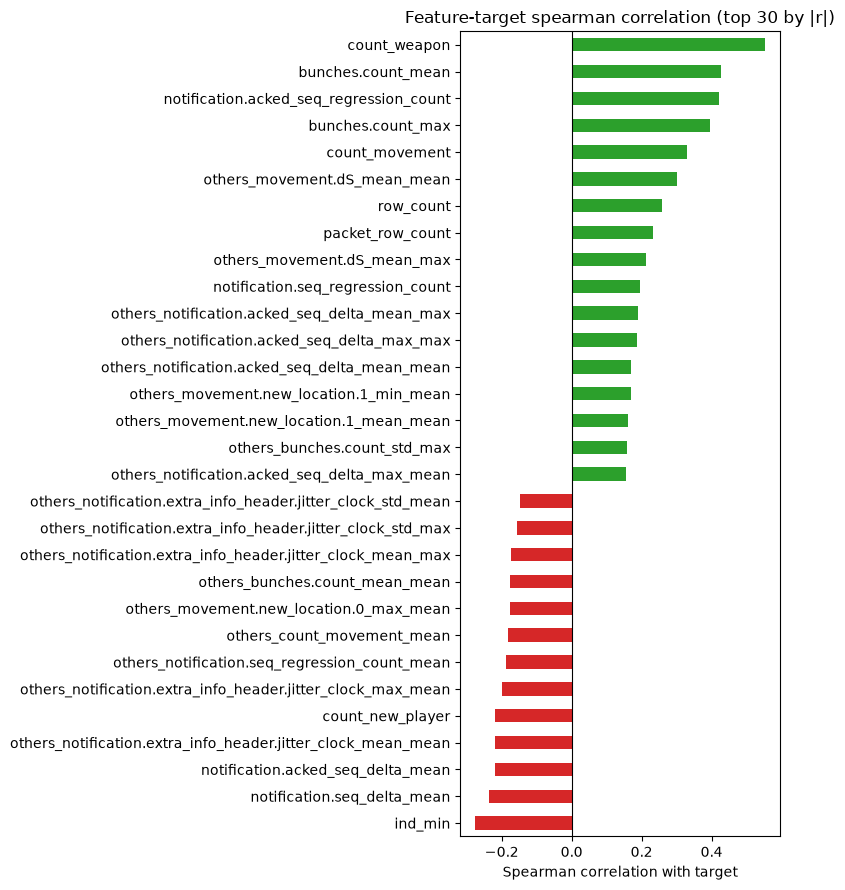

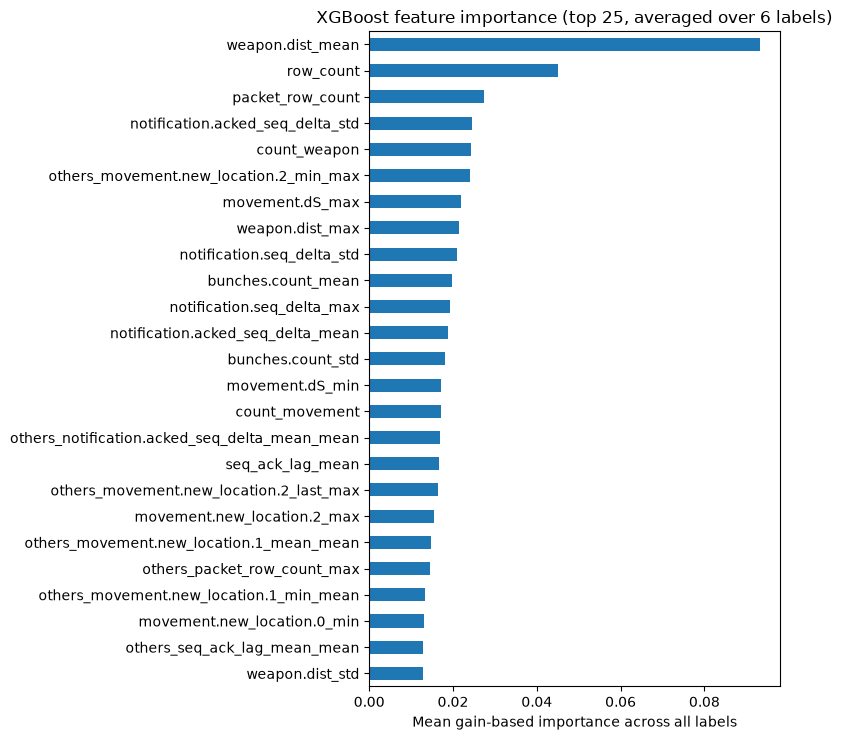

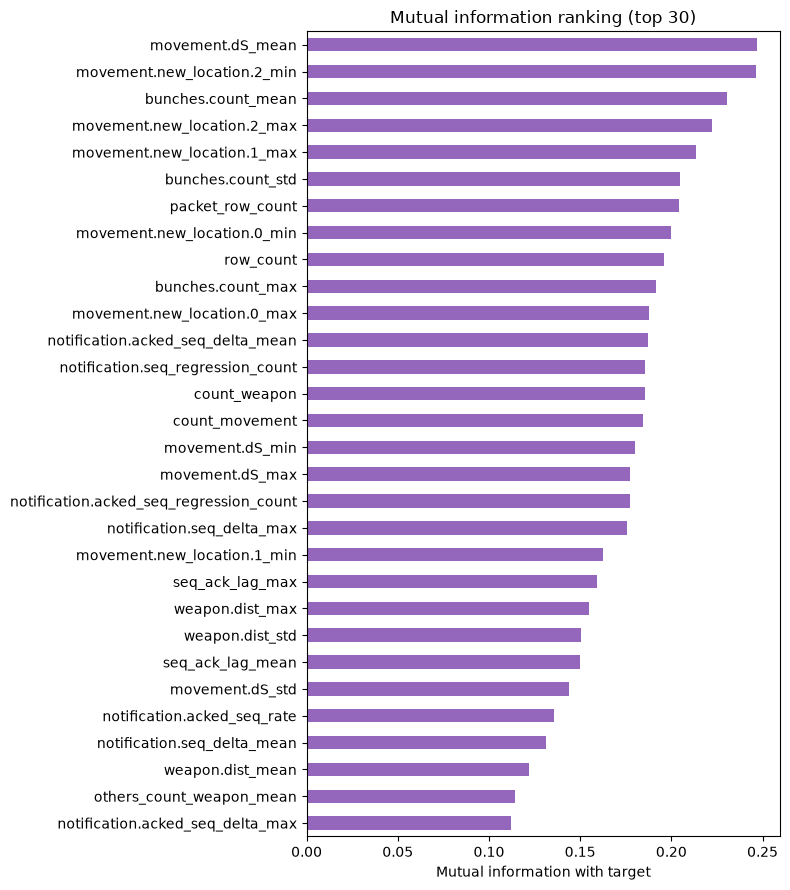

In [29]:
if __name__ == "__main__":
    from sklearn.model_selection import TimeSeriesSplit
    from sklearn.metrics import classification_report
 
    # Explicit dtypes for sparsely-populated wide-log columns avoid the
    # DtypeWarning (pandas guessing a different dtype per chunk) and avoid
    # silent mixed float/str columns downstream.
    df = pd.read_csv(
        "parse_Session_2_Match1_cleaned.csv",
        dtype={
            "phase_event.phase_name": str,
            "new_address.ip": str,
            "new_player.name": str,
            "new_player.ip_port": str,
            "weapon.bone": str,
            "cheat.type": str,
        },
    )
 
    # One row per (window, player) now -- see build_dataset. type_vocab is
    # just exploit types (bounded, dense); "which player" is the row's own
    # identity (X_raw["actor_player_id"]), not something the model outputs.
    X_raw, targets, type_vocab = build_dataset(df)
    X = encode_features(X_raw)
    Y, mlb = encode_targets(targets, type_vocab)
 
    print(label_balance_report(Y, type_vocab))
 
    # Blocked time-series CV: several train/test splits across different
    # portions of the match, instead of trusting a single chronological
    # 80/20 cut that might land on an all-positive (or all-negative) slice.
    # Once you have multiple matches, prefer GroupShuffleSplit(groups=X_raw["match"]).
    order = X_raw.sort_values("window_start_iso").index.to_numpy()
    tscv = TimeSeriesSplit(n_splits=4)
 
    for fold, (train_pos, test_pos) in enumerate(tscv.split(order)):
        train_idx, test_idx = order[train_pos], order[test_pos]
        Y_test = Y[test_idx]
 
        print(f"\n=== Fold {fold} ===")
        fold_diagnostic(Y_test, type_vocab, "exploit type")
 
        clf = MultiOutputClassifier(
            xgb.XGBClassifier(
                tree_method="hist",
                device="cpu",       # switch to "cuda" once available
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                eval_metric="logloss",
            ),
            n_jobs=-1,
        )
        clf.fit(X.loc[train_idx], Y[train_idx])
        preds = clf.predict(X.loc[test_idx])
 
        print("\n-- Exploit type (all players combined) --")
        print(classification_report(Y_test, preds, target_names=type_vocab, zero_division=0))
 
        # Player-only breakdown: just filter rows by actor_player_id -- no
        # label decomposition needed anymore, since player identity IS the
        # row. Shown for the last fold only to avoid flooding output;
        # call per_player_report() directly for any fold you want to inspect.
        if fold == tscv.n_splits - 1:
            per_player_report(X_raw, test_idx, Y_test, preds, type_vocab)
 
    # Final model trained on everything, for actual deployment.
    final_clf = train(X, Y)
    save_model(final_clf, mlb, list(X.columns))
 
    # Feature diagnostics -- run against the same "any cheat occurred"
    # binary target used for the earlier baseline, since per-label MI/
    # correlation across ~17+ sparse labels individually gets noisy fast.
    y_binary = (Y.sum(axis=1) > 0).astype(int)
 
    report_degenerate_features(X)
    plot_target_correlation(X, y_binary, method="spearman")
    plot_feature_correlation_matrix(X, method="spearman")
    plot_feature_importance(final_clf, list(X.columns))
    mutual_information_ranking(X, y_binary)

In [9]:
X_raw["window_other_player_count"].describe()
X_raw["window_other_player_count"].value_counts()

window_other_player_count
5    252
6    105
4     10
Name: count, dtype: int64